In [2]:
!pip install -r ../requirements.txt

import sys
sys.path.append('../src')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import math

import pandas as pd
import numpy as np


In [2]:
from mcTOTHelper import MCTOTHelper

#Get an instance of the helper class, using this particular calibration file
TOThelper = MCTOTHelper("../calibrations/mc_v8_tot_calibration_averaged.csv")

In [16]:
mcdata = pd.read_csv('../analysis_files/muon_4GeV_MC_v9_2.csv')

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

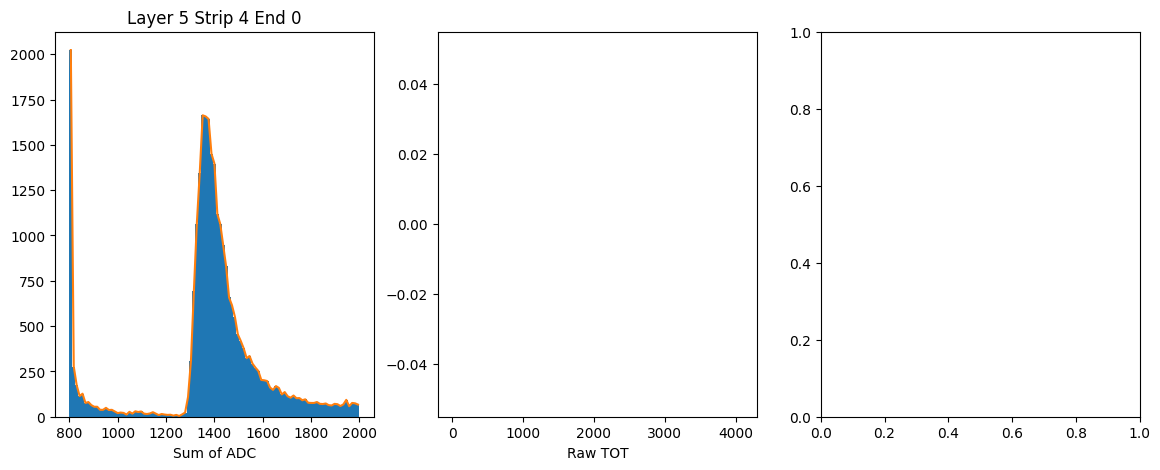

In [86]:
layer = 5
strip = 4
#end = 0

events = mcdata.loc[mcdata['layer'] == layer].loc[mcdata['strip'] == strip]

sum_adc = []
max_adc = []
tot = []
tot_corrected = []

#Go through each pulse
for index, row in events.iterrows():
    #Check if this pulse is in TOT mode (returns -1 otherwise)
    #if TOThelper.get_Tc_index(row,end) != -1:
    #    #If so, get the TOT value out of the pulse
    #    #rawtot = TOThelper.get_TOT(row,end)
    #    #tot.append(rawtot)
    #    #And correct it to sum of ADC
    #    #tot_corrected.append(TOThelper.correct_TOT(layer,strip,end,rawtot))
    #    pass
    #else:
    #sum_adc.append(row["adc_sum_end"+str(end)])
    sum_adc.append((row["adc_sum_end0"]+row["adc_sum_end1"])/2)
    #max_adc.append(row["adc_max_end"+str(end)])
    max_adc.append((row["adc_max_end0"]+row["adc_max_end1"])/2)

fig, axs = plt.subplots(1,3, figsize=(14,5))
adcbins = np.linspace(800,2000,100)
xaxis = [(adcbins[k]+adcbins[k+1])/2 for k in range(0,len(adcbins)-1)]

#sum_adc = [x for x in sum_adc if x > 1200 and x < 2000]

y = axs[0].hist(sum_adc, bins=adcbins)
y = list(y[0])
#axs[0].set_yscale("log")
axs[0].set_xlabel("Sum of ADC")
totbins = np.linspace(0,4096, 50)
axs[1].hist(tot, bins=totbins)
axs[1].set_xlabel("Raw TOT")

#combinedhistbins = np.linspace(500,max(tot_corrected),100)
#axs[2].hist(sum_adc, bins=combinedhistbins, histtype="step", label="ADC")
#axs[2].hist(tot_corrected,bins=combinedhistbins, label="Corrected TOT")
#axs[2].set_yscale("log")
#axs[2].set_xlabel("Sum of ADC")
#axs[2].legend()

axs[0].set_title("Layer " + str(layer) + " Strip " + str(strip) + " End " + str(end))


#plt.hist(max_adc,bins=75)
#plt.yscale("log")

axs[0].plot(xaxis,y)

from scipy.stats import landau, norm
from scipy.optimize import curve_fit
from scipy.signal import convolve

xaxis_cut = xaxis[25:75]
y_cut = y[25:75]

xgrid = np.linspace(xaxis_cut[0],xaxis_cut[-1],100)
gaussgrid = np.linspace(-100,100,100)
#print(xgrid)

def f(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgrid],[norm.pdf(k,0.0,e) for k in gaussgrid], mode='same')
    return np.interp(x,xgrid,convolved)

p = curve_fit(f, xaxis_cut,y_cut, p0=[1350,20,10000,20])

print(p[0])
axs[0].plot(xaxis_cut, [f(x,*p[0]) for x in xaxis_cut])
#axs[0].ylim((0,500))

xmode = 0.0
mode = 0.0
for k in xgrid:
    if f(k,*p[0]) > mode:
        mode = f(k,*p[0])
        xmode = k

axs[0].vlines(xmode,0,500, linestyle="dashed", color="red")
print("Mode: " + str(xmode))

axs[0].set_xlim(1000,1800)
axs[0].set_ylim(0,300)

plt.show()

[1.38025757e+03 5.11825925e+01 8.02166844e+04 1.11727790e+01]
Mode: 1373.063973063973


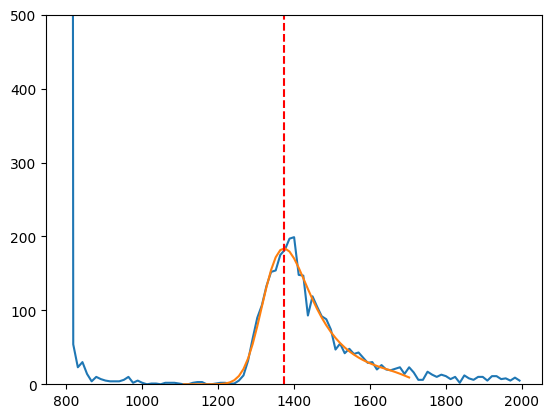

[1371.55390842   67.64986973    2.01294409    4.51274254]


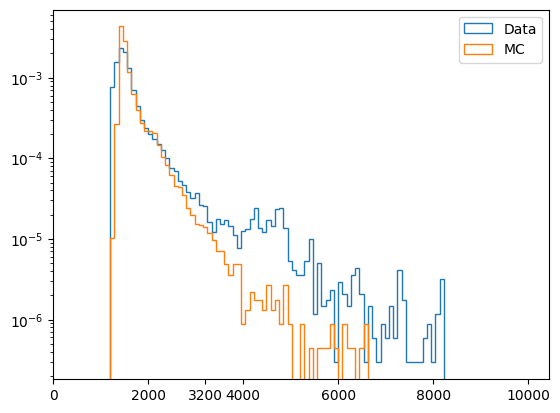

In [100]:
import json
file = open("muonadc.json","r")
data = json.load(file)
file.close()

data = [x for x in data if x > 1200]
sum_adc_filtered = [x*1.05 for x in sum_adc if x > 1200]

import scipy.stats

pe_per_mip = 60

#sum_adc_noise = [x+scipy.stats.norm.rvs()*np.sqrt((x-800)/600*pe_per_mip)*600/pe_per_mip for x in sum_adc_filtered]

#sum_adc_pileup = []
#for x in sum_adc_noise:
#    if scipy.stats.uniform.rvs() < 0.05:
#        sum_adc_pileup.append(x+600)
#    else:
#        sum_adc_pileup.append(x)

bins = np.linspace(1200,10000,100)

plt.hist(data, bins=bins, histtype="step",label="Data", density=True)
#plt.hist(sum_adc_filtered, bins=bins, histtype="step", label="MC", density=True)
h = plt.hist(sum_adc_filtered, bins=bins, histtype="step", label="MC", density=True)
#plt.hist(sum_adc_pileup, bins=bins, histtype="step", label="MC", density=True)

xaxis = [(bins[k]+bins[k+1])/2 for k in range(0,len(bins)-1)]

xaxis_cut = xaxis[10:40]
y_cut = h[0][10:40]

xgrid = np.linspace(xaxis_cut[0],xaxis_cut[-1],100)
gaussgrid = np.linspace(-100,100,100)
#print(xgrid)

def f(x, a, b, c, e):
    convolved = np.convolve([landau.pdf(k,a,b)*c for k in xgrid],[norm.pdf(k,0.0,e) for k in gaussgrid], mode='same')
    return np.interp(x,xgrid,convolved)

#p = curve_fit(f, xaxis_cut,y_cut, p0=[1350,20,0.002,20])

print(p[0])
#plt.plot(xaxis_cut, [f(x,*p[0]) for x in xaxis_cut])
#plt.plot(xaxis_cut, [f(x,*[1400,5,5,1]) for x in xaxis_cut])

plt.yscale("log")
plt.legend()
plt.xticks([0,2000,3200,4000,6000,8000,10000])
#plt.ylim(1e-6,5e-3)
#plt.xlim(1000,1023*8)
#plt.xlim(0,1023)
plt.show()